# Introduction to time series clustering

Time series data are ubiquitous in many fields, including finance, weather forecasting, signal processing, and manufacturing. Clustering, a technique used in unsupervised learning, involves grouping similar objects together. In the context of time series data, clustering aims to group similar time series together based on their patterns and shapes, and can be used for various applications, such as anomaly detection, forecasting, and pattern recognition.

Time series clustering is a challenging task due to the temporal dependencies and varying lengths of time series, and the need to capture both local and global patterns. There are various approaches to time series clustering, including:

- Distance-based methods: compute the similarity between time series using a distance measure, such as Euclidean distance or dynamic time warping, and group similar time series together.
- Model-based methods: Fit a probabilistic model to the time series and use clustering algorithms to group the model parameters.
- Feature-based methods: extract features from the time series, such as Fourier coefficients or wavelet coefficients, and use clustering algorithms to group the features.

We will focus on distance-based methods as they are one of the most commonly used approaches for time series clustering. These methods compute a distance or similarity measure between time series, and then group them based on their distances. One of the most popular distance measures for time series clustering is dynamic time warping (DTW).

To compute the DTW distance between two time series, we first create a two-dimensional matrix, called the DTW matrix, where the $(i,j)$-th element of the matrix stores the distance between the $i$-th point in the first time series and the $j$-th point in the second time series. We then compute the minimum cost path through this matrix, which corresponds to the best alignment between the two time series. The DTW distance is the sum of the distances along the minimum cost path.

DTW has several advantages over other distance measures, particularly when the time series have variable lengths, non-linear distortions (robust to noise), or different time scales. However, it can be computationally expensive, especially for long time series or large datasets. Therefore, various optimizations have been proposed to make DTW more efficient, such as using lower bounds, pruning, or early abandoning.

Overall, distance-based methods, particularly DTW, are widely used in time series clustering because they are flexible, versatile, and intuitive. However, the choice of distance measure depends on the specific characteristics of the time series and the clustering task at hand.

Before we enter in more details about DTW let us define the base objects. Let us consider the time series $x = (x_0, \dots, x_{n-1})$ and $y = (y_0, \dots, y_{n-1})$ depicted as follows:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tslearn.metrics import dtw, dtw_path

from tsclustering.utils.paths import reports_figures_dir
from tsclustering.visualization.visualize import MEMBER_GREY, PALETTE, set_style

set_style()

In [2]:
fs = 100
time = np.arange(0, 1, 1/fs)
sinusoid = np.sin(2*np.pi*2*time)

x = np.concatenate((np.zeros(20), sinusoid, np.zeros(50)))
y = np.concatenate((np.zeros(50), sinusoid, np.zeros(20)))
t = np.arange(0, len(x)/fs, 1/fs)

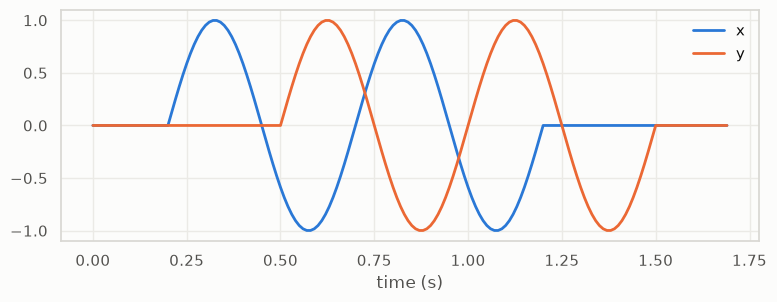

In [3]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, x, color=PALETTE[0], label="x")
ax.plot(t, y, color=PALETTE[1], label="y")
ax.set_xlabel("time (s)")
ax.legend(frameon=False)
plt.show()

In this example both time series have the same sinusoidal feature at different time instants. The two series should count as similar, because their only difference is the time shift.

**Experiment: which samples does each distance compare?** The grey lines link the pairs of samples each distance compares. For clarity, `x` is drawn above `y` and only every third link is shown.

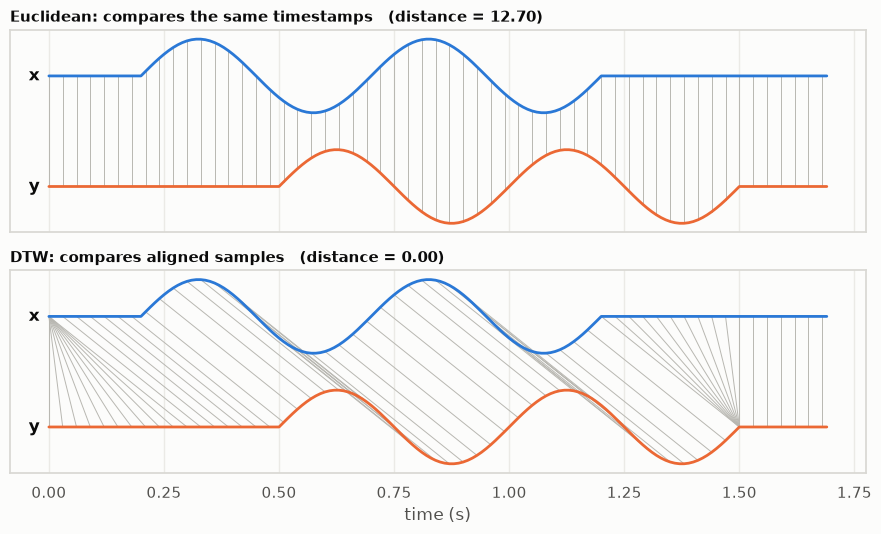

In [4]:
path, _ = dtw_path(x, y)
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
cases = [
    ("Euclidean: compares the same timestamps", [(i, i) for i in range(len(x))], np.linalg.norm(x - y)),
    ("DTW: compares aligned samples", path, dtw(x, y)),
]
for ax, (name, pairs, dist) in zip(axes, cases):
    for i, j in pairs[::3]:
        ax.plot([t[i], t[j]], [x[i] + 1.5, y[j] - 1.5], color=MEMBER_GREY, lw=0.7)
    ax.plot(t, x + 1.5, color=PALETTE[0])
    ax.plot(t, y - 1.5, color=PALETTE[1])
    ax.text(-0.02, 1.5, "x", ha="right", va="center", fontweight="bold")
    ax.text(-0.02, -1.5, "y", ha="right", va="center", fontweight="bold")
    ax.set_title(f"{name}   (distance = {dist:.2f})", loc="left")
    ax.set_yticks([])
axes[1].set_xlabel("time (s)")
fig.tight_layout()
fig.savefig(reports_figures_dir("euclidean_vs_dtw.png"), dpi=150, bbox_inches="tight")
plt.show()

Euclidean distance pairs samples at the same timestamp, so the shift makes the two waves look very different (distance ≈ 12.7). DTW warps the time axis so each peak is matched with its counterpart, and the distance drops to 0. This property is what lets DTW-based clustering group series by *shape* rather than by *timing*. The next notebook shows how the alignment is computed.